# Measuring Data Quality — SO-101 PCB dataset

Turns *Data Quality in Imitation Learning* (Belkhale et al.) into numbers on your own data.
See **[07_measure_data_quality.md](07_measure_data_quality.md)** for the plain-language plan.

**Dataset:** `so101_pick_place_pcb_20260721_183543` (v3.0, 161 episodes / 111,776 frames).

**Sections**
1. Load & preprocess (→ one `.npz` cache; run once)
2. State diversity (visual + robot-state, group comparison)
3. Action divergence (visual vs robot-state, **episode×time heatmap**)
4. Transition diversity (initial-state spread)

> **Kernel:** select the `lerobot` conda env. If it's not offered in VS Code, run once in a terminal:
> `C:/Users/bingjian/miniconda3/envs/lerobot/python.exe -m pip install ipykernel matplotlib scikit-learn`


## Section 0 — Setup

In [2]:
# Install the few missing deps into the current (lerobot) kernel. Safe to re-run.
%pip install -q matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os, glob, json, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt

# ---- CONFIG (edit these) ---------------------------------------------------
DATASET_ROOT = r"C:/Users/bingjian/.cache/huggingface/lerobot/HALDijkstraaa/so101_pick_place_pcb_20260721_183543"
REPO_ID      = "HALDijkstraaa/so101_pick_place_pcb_20260721_183543"
CACHE        = os.path.join(os.getcwd(), "dq_cache.npz")   # embeddings cache (Section 1 writes it)

FRAMES_PER_EPISODE = 40          # uniform subsample per episode (raise for more precision, slower)
DINO_MODEL         = "facebook/dinov2-small"   # 384-d ViT-S/14
KNN_K              = 15          # neighbors for action-divergence
IMG_KEY            = "observation.images.front"

# Episode-index -> group label. Verify ranges against the thumbnail grid (end of Section 1).
# Unlisted episodes (e.g. negatives / gaps: 50, 81, 111-120, 151-160) fall into "other" and are
# excluded from the per-group comparisons.
GROUPS = {
    "home (ep 0-49)":  range(0, 50),    # good side angle (original v2 data)
    "nb1 (ep 51-80)":  range(51, 81),   # Noisebridge env 1
    "nb2 (ep 82-110)": range(82, 111),  # Noisebridge env 2
    "nb3 (ep 121-150)": range(121, 151),# Noisebridge env 3
}

DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
print("device:", DEVICE, "| cache:", CACHE)

def group_of(ep: int) -> str:
    for name, rng in GROUPS.items():
        if ep in rng: return name
    return "other"


device: cuda | cache: d:\JobApplications\Pytorch_Training\smolvla_so101\dq_cache.npz


## Section 1 — Load & preprocess  *(run once; writes `dq_cache.npz`)*

Reads the parquet tables, uniformly subsamples ~40 frames/episode, decodes each frame's image
(LeRobot + PyAV), computes a **DINOv2** visual embedding, keeps the **6-DoF joint state** and the
**per-dim-normalized action**, and caches all of it. Later sections load only the cache.

In [4]:
# ---- 1a. Build the per-frame table from the data parquets (state/action are always available)
data_files = sorted(glob.glob(os.path.join(DATASET_ROOT, "data", "chunk-*", "file-*.parquet")))
cols = ["episode_index", "frame_index", "index", "action", "observation.state"]
tbl = pd.concat([pd.read_parquet(f, columns=cols) for f in data_files], ignore_index=True)
tbl = tbl.sort_values("index").reset_index(drop=True)

# per-episode length (for normalized-time in the heatmap)
ep_len = tbl.groupby("episode_index")["frame_index"].max().add(1).to_dict()
print(f"{tbl['episode_index'].nunique()} episodes, {len(tbl)} frames total")

# ---- 1b. Uniform subsample of frames per episode
rng = np.random.default_rng(0)
sel = []
for ep, g in tbl.groupby("episode_index"):
    idx = g["index"].to_numpy()
    take = np.linspace(0, len(idx) - 1, min(FRAMES_PER_EPISODE, len(idx))).round().astype(int)
    sel.append(idx[np.unique(take)])
sel = np.concatenate(sel)
sub = tbl.set_index("index").loc[sel].reset_index()
print(f"subsampled {len(sub)} frames (~{FRAMES_PER_EPISODE}/episode)")

actions = np.stack(sub["action"].to_numpy()).astype(np.float32)          # (M,6)
states  = np.stack(sub["observation.state"].to_numpy()).astype(np.float32) # (M,6)
episodes = sub["episode_index"].to_numpy()
frames   = sub["frame_index"].to_numpy()
global_idx = sub["index"].to_numpy()
time_frac = np.array([frames[i] / max(1, ep_len[episodes[i]] - 1) for i in range(len(sub))], dtype=np.float32)


161 episodes, 111776 frames total
subsampled 6401 frames (~40/episode)


In [5]:
# ---- 1c. Load DINOv2 and the LeRobot dataset (for image decoding via PyAV)
import torch
from transformers import AutoImageProcessor, AutoModel
from lerobot.datasets.lerobot_dataset import LeRobotDataset

if os.path.exists(CACHE):
    print("cache exists -> skipping embedding. Delete", CACHE, "to recompute.")
else:
    proc  = AutoImageProcessor.from_pretrained(DINO_MODEL)
    model = AutoModel.from_pretrained(DINO_MODEL).to(DEVICE).eval()
    ds    = LeRobotDataset(REPO_ID, root=DATASET_ROOT)

    @torch.no_grad()
    def embed_batch(pil_list):
        inp = proc(images=pil_list, return_tensors="pt").to(DEVICE)
        out = model(**inp)
        emb = out.pooler_output if getattr(out, "pooler_output", None) is not None \
              else out.last_hidden_state[:, 0]           # CLS fallback
        return torch.nn.functional.normalize(emb, dim=-1).cpu().numpy()  # L2-norm -> cosine-ready

    from PIL import Image
    embs, batch, B = [], [], 32
    from tqdm.auto import tqdm
    for j, gi in enumerate(tqdm(global_idx, desc="embedding frames")):
        img = ds[int(gi)][IMG_KEY]                        # (3,H,W) float[0,1]
        arr = (img.clamp(0, 1) * 255).byte().permute(1, 2, 0).numpy()
        batch.append(Image.fromarray(arr))
        if len(batch) == B or j == len(global_idx) - 1:
            embs.append(embed_batch(batch)); batch = []
    vis_emb = np.concatenate(embs).astype(np.float32)     # (M,384), L2-normalized
    print("visual embeddings:", vis_emb.shape)

    # ---- 1d. Normalize actions per-dim (variance is what matters -> divide by std)
    act_std = actions.std(0) + 1e-6
    actions_norm = actions / act_std

    np.savez_compressed(CACHE, vis_emb=vis_emb, actions=actions, actions_norm=actions_norm,
                        states=states, episodes=episodes, frames=frames, time_frac=time_frac,
                        global_idx=global_idx, act_std=act_std)
    print("saved ->", CACHE)


cache exists -> skipping embedding. Delete d:\JobApplications\Pytorch_Training\smolvla_so101\dq_cache.npz to recompute.


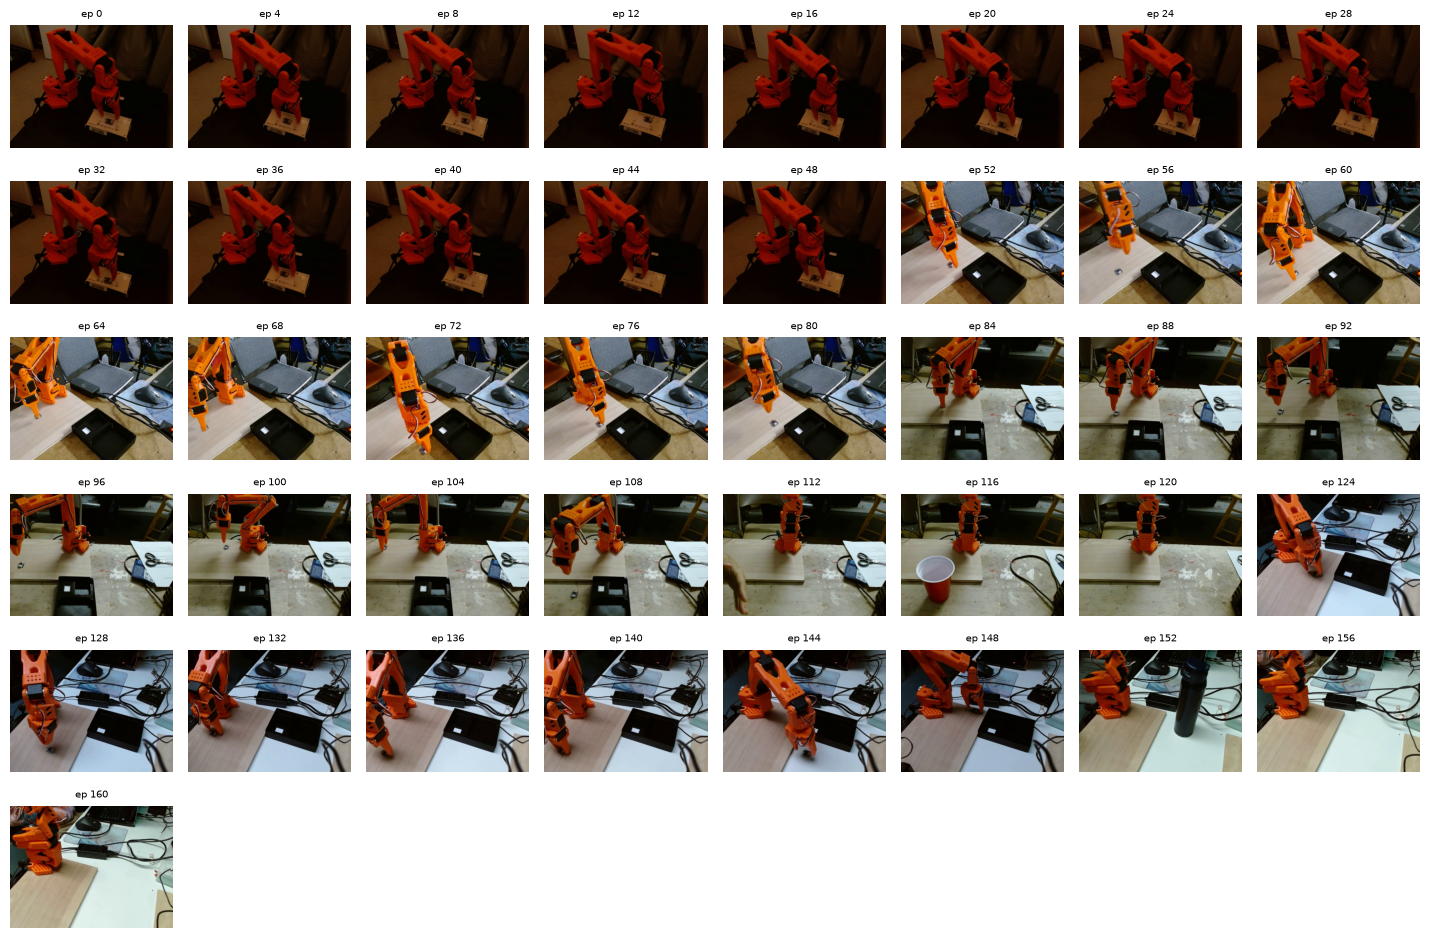

In [6]:
# ---- 1e. (optional) Thumbnail grid: one frame per episode -> identify camera-angle groups
# Run this to SEE your episodes, then edit GROUPS in Section 0 accordingly.
from lerobot.datasets.lerobot_dataset import LeRobotDataset
ds = LeRobotDataset(REPO_ID, root=DATASET_ROOT)
step = 4                                   # show every 4th episode (set 1 to see all)
eps_to_show = list(range(0, int(tbl['episode_index'].max()) + 1, step))
ncol = 8; nrow = int(np.ceil(len(eps_to_show) / ncol))
fig, ax = plt.subplots(nrow, ncol, figsize=(ncol * 1.8, nrow * 1.6))
for a, ep in zip(ax.ravel(), eps_to_show):
    gi = int((tbl[tbl.episode_index == ep]["index"].iloc[len(tbl[tbl.episode_index==ep]) // 3]))  # ~1/3 in
    img = ds[gi][IMG_KEY].clamp(0, 1).permute(1, 2, 0).numpy()
    a.imshow(img); a.set_title(f"ep {ep}", fontsize=7); a.axis("off")
for a in ax.ravel()[len(eps_to_show):]: a.axis("off")
plt.tight_layout(); plt.show()


## Section 2 — State diversity

*How much ground does the data cover?* Visual diversity = mean pairwise **cosine distance** of DINOv2
embeddings (0 = identical, →1 = diverse). Robot-state diversity = mean pairwise distance of normalized
joint vectors. High visual diversity is **not** automatically good (paper's caveat) — check it against
action divergence in Section 3.

In [2]:
# Load cache and prep group masks + normalized robot-state
Z = np.load(CACHE, allow_pickle=True)
vis_emb, actions, actions_norm = Z["vis_emb"], Z["actions"], Z["actions_norm"]
states, episodes, frames, time_frac = Z["states"], Z["episodes"], Z["frames"], Z["time_frac"]
state_norm = (states - states.mean(0)) / (states.std(0) + 1e-6)     # z-scored joints
labels = np.array([group_of(int(e)) for e in episodes])
present = [g for g in GROUPS if (labels == g).any()]
print("groups present:", present, "| total frames:", len(labels))

def mean_pairwise(X, metric="euclidean", cap=1500, seed=0):
    r = np.random.default_rng(seed)
    if len(X) > cap: X = X[r.choice(len(X), cap, replace=False)]
    from sklearn.metrics import pairwise_distances
    D = pairwise_distances(X, metric=metric)
    iu = np.triu_indices(len(X), k=1)
    return float(D[iu].mean())


groups present: ['home (ep 0-49)', 'nb1 (ep 51-80)', 'nb2 (ep 82-110)', 'nb3 (ep 121-150)'] | total frames: 6401


,group,n,visual_div,state_div
0,home (ep 0-49),2000,0.168,2.616
1,nb1 (ep 51-80),1200,0.152,3.002
2,nb2 (ep 82-110),1160,0.170,3.378
3,nb3 (ep 121-150),1200,0.212,3.301


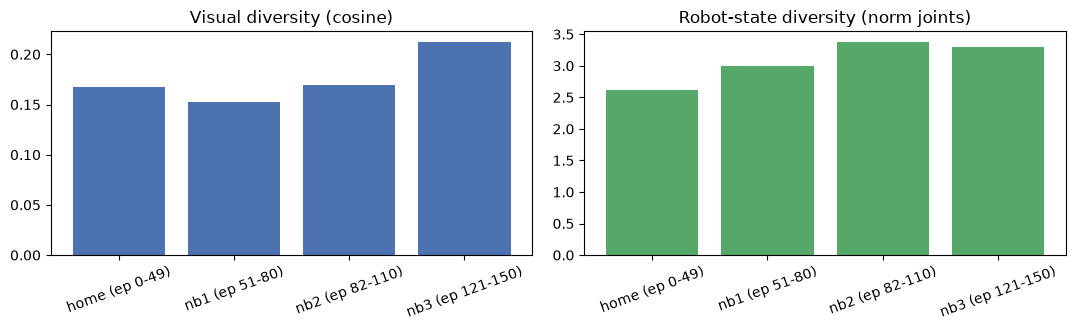

In [3]:
# Compute per-group diversity and bar-chart it
rows = []
for g in present:
    m = labels == g
    rows.append(dict(group=g, n=int(m.sum()),
                     visual_div=mean_pairwise(vis_emb[m], "cosine"),
                     state_div=mean_pairwise(state_norm[m], "euclidean")))
div = pd.DataFrame(rows); display(div.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(div.group, div.visual_div, color="#4C72B0"); ax[0].set_title("Visual diversity (cosine)")
ax[1].bar(div.group, div.state_div,  color="#55A868"); ax[1].set_title("Robot-state diversity (norm joints)")
for a in ax: a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


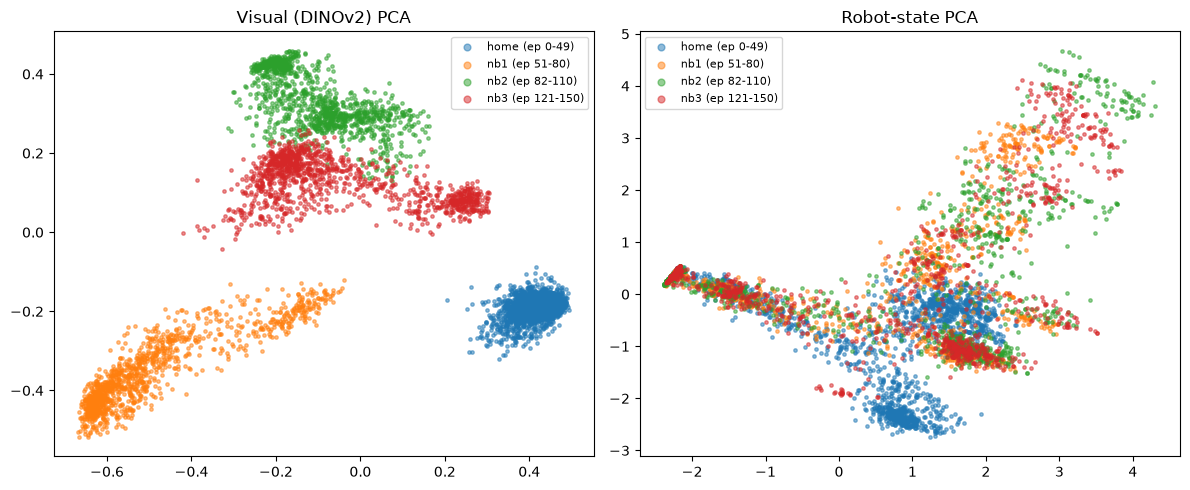

In [4]:
# 2-D PCA scatter: do the up-front-camera frames collapse into a tight VISUAL blob?
from sklearn.decomposition import PCA
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, (X, title) in zip(ax, [(vis_emb, "Visual (DINOv2) PCA"), (state_norm, "Robot-state PCA")]):
    P = PCA(2).fit_transform(X)
    for g in present:
        m = labels == g
        a.scatter(P[m, 0], P[m, 1], s=6, alpha=0.5, label=g)
    a.set_title(title); a.legend(fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()


## Section 3 — Action divergence  *(the headline)*

For each frame: k nearest neighbors **in state space** → std of their normalized actions ÷ global std
→ a **0–1 ambiguity ratio**. ~0 = look-alike states map to the same action (consistent); →1 = look-alike
states map to different actions (multimodal → mushy grasp).

Computed **twice**: neighbors in **visual** space vs **robot-state** space. The occlusion problem should
inflate the *visual* number (occluded PCB → identical-looking frames, different actions) while the
*robot-state* number stays low (the joints still tell the states apart).

In [5]:
from sklearn.neighbors import NearestNeighbors

def action_divergence(space_X, actions_norm, k=KNN_K):
    # local action std among k nearest neighbors in space_X, normalized by the global action std
    metric = "cosine" if space_X.shape[1] > 20 else "euclidean"   # cosine for image emb, L2 for joints
    nn = NearestNeighbors(n_neighbors=k + 1, metric=metric).fit(space_X)
    _, idx = nn.kneighbors(space_X)
    idx = idx[:, 1:]                                              # drop self
    # per-frame: mean over action-dims of the neighbor variance, then sqrt -> a scalar std
    local = np.sqrt(actions_norm[idx].var(axis=1).mean(axis=1))   # (M,)
    global_scale = np.sqrt(actions_norm.var(0).mean())
    return local / global_scale

div_vis   = action_divergence(vis_emb,    actions_norm)   # neighbors in VISUAL space
div_state = action_divergence(state_norm, actions_norm)   # neighbors in ROBOT-STATE space
print("mean divergence  visual:", round(div_vis.mean(), 3), "| robot-state:", round(div_state.mean(), 3))


mean divergence  visual: 0.256 | robot-state: 0.09


,group,n,div_visual,div_state
0,home (ep 0-49),2000,0.256,0.096
1,nb1 (ep 51-80),1200,0.303,0.103
2,nb2 (ep 82-110),1160,0.331,0.117
3,nb3 (ep 121-150),1200,0.312,0.105


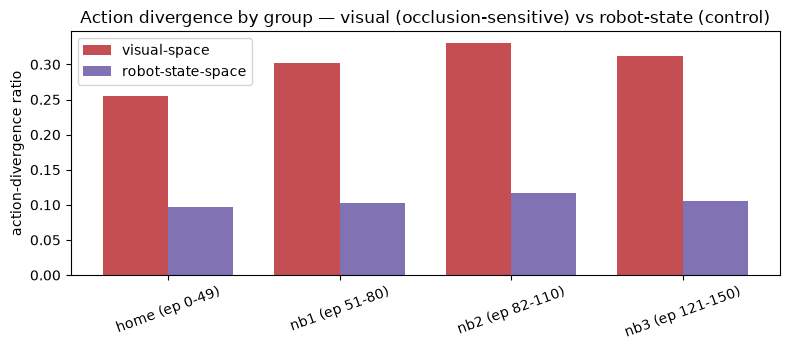

In [6]:
# Per-group mean divergence: the key comparison
rows = []
for g in present:
    m = labels == g
    rows.append(dict(group=g, n=int(m.sum()),
                     div_visual=float(div_vis[m].mean()),
                     div_state=float(div_state[m].mean())))
dd = pd.DataFrame(rows); display(dd.round(3))

x = np.arange(len(present)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(x - w/2, dd.div_visual, w, label="visual-space", color="#C44E52")
ax.bar(x + w/2, dd.div_state,  w, label="robot-state-space", color="#8172B3")
ax.set_xticks(x); ax.set_xticklabels(dd.group, rotation=20); ax.set_ylabel("action-divergence ratio")
ax.set_title("Action divergence by group — visual (occlusion-sensitive) vs robot-state (control)")
ax.legend(); plt.tight_layout(); plt.show()


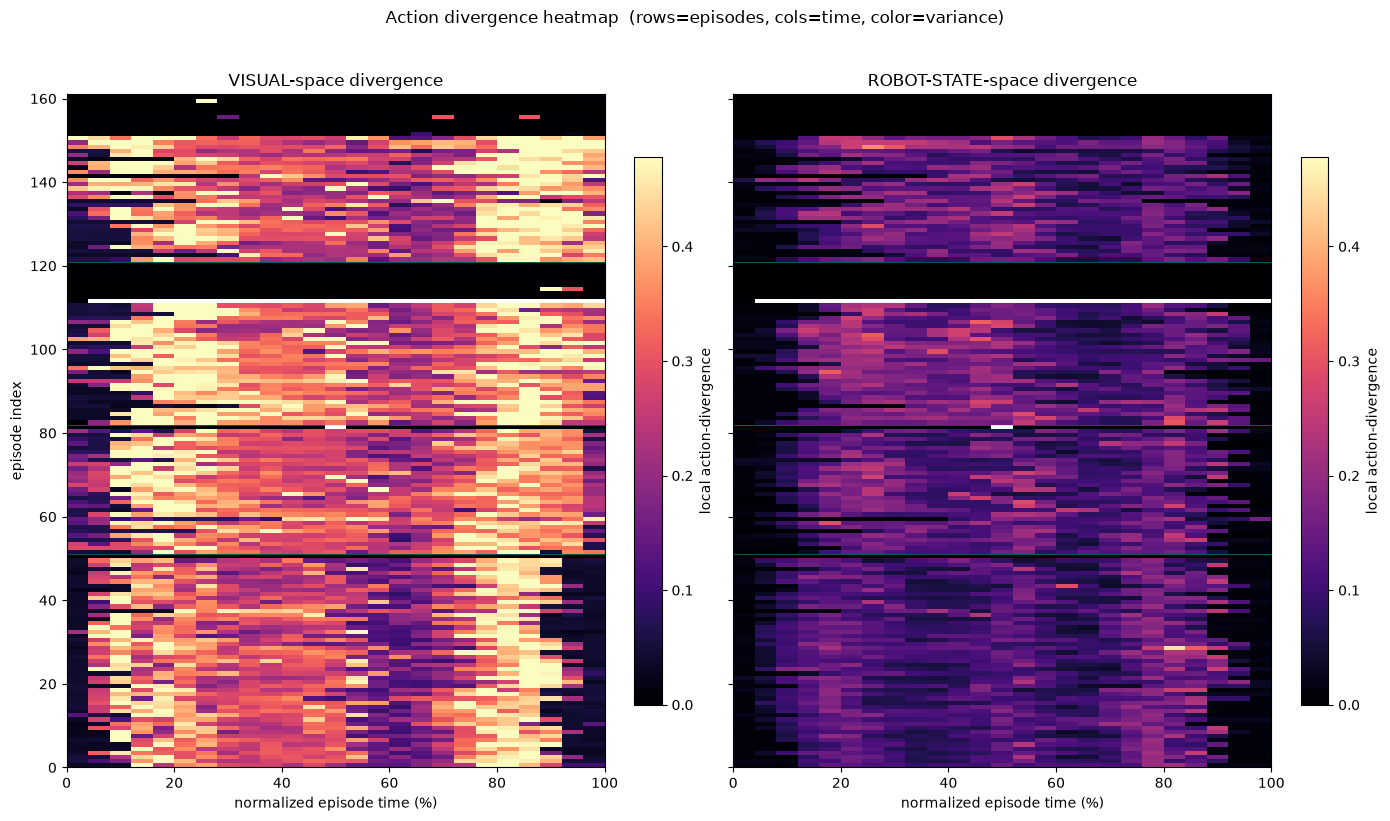

In [7]:
# The episode x normalized-time heatmap: WHEN and WHERE does divergence spike?
N_BINS = 25
def divergence_heatmap(div):
    eps_sorted = np.sort(np.unique(episodes))
    row_of = {e: i for i, e in enumerate(eps_sorted)}
    H = np.full((len(eps_sorted), N_BINS), np.nan)
    b = np.clip((time_frac * N_BINS).astype(int), 0, N_BINS - 1)
    for e in eps_sorted:
        m = episodes == e
        for bi in range(N_BINS):
            v = div[m & (b == bi)]
            if len(v): H[row_of[e], bi] = v.mean()
    return eps_sorted, H

eps_sorted, Hv = divergence_heatmap(div_vis)
_,          Hs = divergence_heatmap(div_state)
vmax = np.nanpercentile(np.concatenate([Hv, Hs]), 95)   # shared scale

fig, ax = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
for a, (H, title) in zip(ax, [(Hv, "VISUAL-space divergence"), (Hs, "ROBOT-STATE-space divergence")]):
    im = a.imshow(H, aspect="auto", origin="lower", cmap="magma", vmin=0, vmax=vmax,
                  extent=[0, 100, eps_sorted[0], eps_sorted[-1] + 1])
    a.set_xlabel("normalized episode time (%)"); a.set_title(title)
    fig.colorbar(im, ax=a, fraction=0.046, label="local action-divergence")
    # draw group boundaries
    for g in present:
        idxs = [e for e in eps_sorted if group_of(int(e)) == g]
        if idxs: a.axhline(min(idxs), color="cyan", lw=0.5, alpha=0.5)
ax[0].set_ylabel("episode index")
plt.suptitle("Action divergence heatmap  (rows=episodes, cols=time, color=variance)", y=1.02)
plt.tight_layout(); plt.show()


VISUAL-space divergence by quartile (groups x quartiles):


,Q1 0-25%,Q2 25-50%,Q3 50-75%,Q4 75-100%
home (ep 0-49),0.258,0.281,0.215,0.267
nb1 (ep 51-80),0.283,0.310,0.275,0.342
nb2 (ep 82-110),0.281,0.367,0.284,0.390
nb3 (ep 121-150),0.275,0.297,0.253,0.423


ROBOT-STATE-space divergence by quartile (groups x quartiles):


,Q1 0-25%,Q2 25-50%,Q3 50-75%,Q4 75-100%
home (ep 0-49),0.084,0.100,0.105,0.097
nb1 (ep 51-80),0.073,0.130,0.123,0.086
nb2 (ep 82-110),0.089,0.170,0.114,0.094
nb3 (ep 121-150),0.073,0.149,0.116,0.083


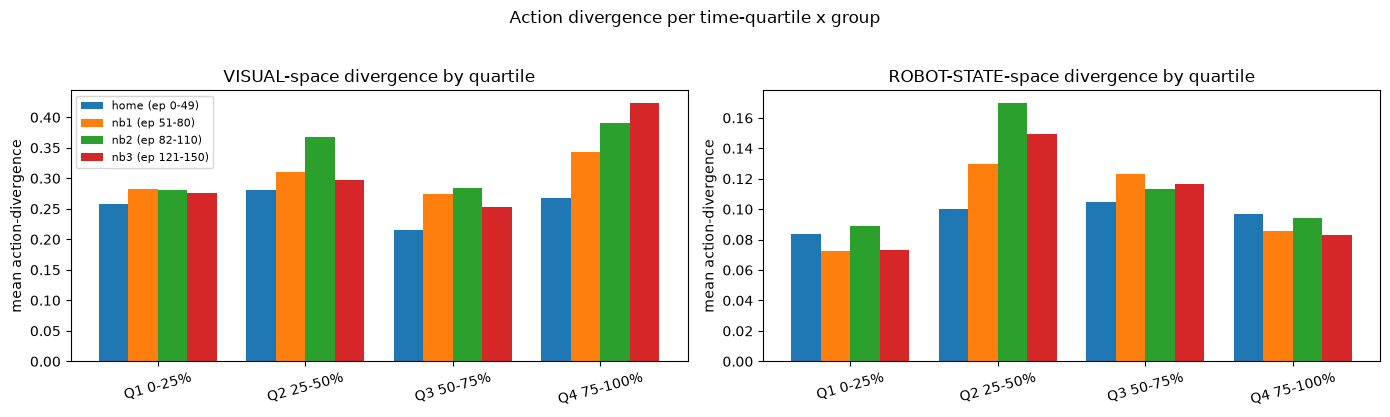

In [8]:
# Per-quartile action divergence: coarse (4-bin) view of WHEN divergence happens, per group.
# Rows = groups, cols = time-quartile (Q1=0-25% ... Q4=75-100%); value = mean local action-divergence.
# Produced for BOTH spaces (visual = occlusion-sensitive, robot-state = physical control).
qbin = np.clip((time_frac * 4).astype(int), 0, 3)                 # 0..3 per frame
QNAMES = ["Q1 0-25%", "Q2 25-50%", "Q3 50-75%", "Q4 75-100%"]

def quartile_table(div):
    M = np.full((len(present), 4), np.nan)
    for gi, g in enumerate(present):
        for q in range(4):
            v = div[(labels == g) & (qbin == q)]
            if len(v): M[gi, q] = v.mean()
    return pd.DataFrame(M, index=present, columns=QNAMES)

qt_vis, qt_state = quartile_table(div_vis), quartile_table(div_state)
print("VISUAL-space divergence by quartile (groups x quartiles):");     display(qt_vis.round(3))
print("ROBOT-STATE-space divergence by quartile (groups x quartiles):"); display(qt_state.round(3))

# grouped bars: x = quartile, one bar per group; two panels (own y-scale, since visual >> state)
x = np.arange(4); w = 0.2
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, (qt, title) in zip(ax, [(qt_vis, "VISUAL-space"), (qt_state, "ROBOT-STATE-space")]):
    for gi, g in enumerate(present):
        a.bar(x + (gi - 1.5) * w, qt.loc[g].values, w, label=g)
    a.set_xticks(x); a.set_xticklabels(QNAMES, rotation=15)
    a.set_title(title + " divergence by quartile"); a.set_ylabel("mean action-divergence")
ax[0].legend(fontsize=8)
plt.suptitle("Action divergence per time-quartile x group", y=1.03)
plt.tight_layout(); plt.show()


## Section 4 — Transition diversity (initial-state spread)

True transition diversity ≈ 0 for a position-controlled arm, so we measure the safe-coverage lever the
theory endorses: **how varied are the starting conditions?** = spread of the **first-frame state** across
episodes, per group. Higher = more initial-state variety (good coverage without raising action divergence).

,group,n_episodes,init_spread
0,home (ep 0-49),50,0.155
1,nb1 (ep 51-80),30,0.190
2,nb2 (ep 82-110),29,0.218
3,nb3 (ep 121-150),30,0.225


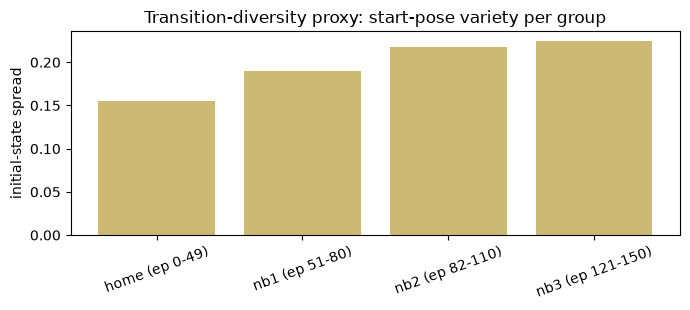

In [9]:
# First-frame (frame_index==0) state per episode, spread per group
first_mask = frames == 0
first_states = state_norm[first_mask]
first_eps    = episodes[first_mask]
first_lab    = np.array([group_of(int(e)) for e in first_eps])

rows = []
for g in present:
    m = first_lab == g
    if m.sum() < 2: continue
    rows.append(dict(group=g, n_episodes=int(m.sum()),
                     init_spread=mean_pairwise(first_states[m], "euclidean", cap=500)))
isp = pd.DataFrame(rows); display(isp.round(3))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(isp.group, isp.init_spread, color="#CCB974")
ax.set_ylabel("initial-state spread"); ax.set_title("Transition-diversity proxy: start-pose variety per group")
ax.tick_params(axis="x", rotation=20); plt.tight_layout(); plt.show()


## How to read the results (hypothesis check)

- **Section 3 bar chart:** if the up-front-camera group shows **high visual-space divergence** but
  **normal robot-state divergence**, that's the fingerprint of *observation-space information loss*
  (occlusion), not inconsistent teleoperation.
- **Section 3 heatmap:** expect the divergence to concentrate in the **reach/grasp phase** (mid-episode)
  and to light up the up-front-camera episode band in the **visual** panel only.
- **Section 2:** the up-front group may show *deceptively low* visual diversity (collapsed embeddings) —
  a concrete example of why raw "state diversity" is a coarse quality signal.

If confirmed: drop / re-film the flagged episodes (the CUPID step) before scaling to the full 8-env plan.
